# Vector DB Test
- CLI 실행 후 테스트 필요 (Docker Compose 컨테이너 실행)
```
wget https://github.com/milvus-io/milvus/releases/download/v2.4.6/milvus-standalone-docker-compose.yml -O docker-compose.yml

docker-compose up -d

docker ps
```


In [1]:
import os
import sys
from pathlib import Path

# 현재 노트북이 있는 경로 기준으로 프로젝트 루트(recsys) 경로 계산
current_dir = (
    os.path.dirname(os.path.abspath(__file__))
    if "__file__" in globals()
    else os.getcwd()
)
project_root = os.path.abspath(os.path.join(current_dir, ".."))

# recsys 폴더를 sys.path에 추가
if project_root not in sys.path:
    sys.path.append(project_root)

from setup_env import setup_env

root_dir = setup_env()

from utils.dataset.config import DatasetPath
from utils.dataset.plot import show_items
from utils.retriever.vector_db import build_filter_expr, search_milvus

[INFO] Font applied: NanumGothic


In [2]:
from pymilvus import (
    connections,
    FieldSchema,
    CollectionSchema,
    DataType,
    Collection,
    utility,
)
import pandas as pd
import numpy as np

# -----------------------------------------------
# Milvus 연결
# -----------------------------------------------
print(">>> Connecting to Milvus...")
connections.connect(alias="default", host="localhost", port="19530")
print(">>> Connected to Milvus")

# -----------------------------------------------
# 기존 컬렉션 삭제
# -----------------------------------------------
COLLECTION_NAME = "fashion_items"
if utility.has_collection(COLLECTION_NAME):
    print(
        f">>> Collection '{COLLECTION_NAME}' already exists. Dropping and recreating..."
    )
    utility.drop_collection(COLLECTION_NAME)

# -----------------------------------------------
# 컬렉션 스키마 정의
# -----------------------------------------------
DIM = 768

fields = [
    FieldSchema(name="item_id", dtype=DataType.INT64, is_primary=True, auto_id=False),
    FieldSchema(name="name", dtype=DataType.VARCHAR, max_length=200),
    FieldSchema(name="brand_name", dtype=DataType.VARCHAR, max_length=100),
    FieldSchema(name="price", dtype=DataType.INT64),
    FieldSchema(name="discount_price", dtype=DataType.INT64),
    FieldSchema(name="gender", dtype=DataType.VARCHAR, max_length=50),
    FieldSchema(name="age_group", dtype=DataType.VARCHAR, max_length=50),
    FieldSchema(name="base_color", dtype=DataType.VARCHAR, max_length=50),
    FieldSchema(name="season", dtype=DataType.VARCHAR, max_length=50),
    FieldSchema(name="year", dtype=DataType.VARCHAR, max_length=10),
    FieldSchema(name="usage", dtype=DataType.VARCHAR, max_length=50),
    FieldSchema(name="master_category", dtype=DataType.VARCHAR, max_length=50),
    FieldSchema(name="sub_category", dtype=DataType.VARCHAR, max_length=50),
    FieldSchema(name="article_type", dtype=DataType.VARCHAR, max_length=50),
    FieldSchema(name="fit", dtype=DataType.VARCHAR, max_length=50),
    FieldSchema(name="occasion", dtype=DataType.VARCHAR, max_length=50),
    FieldSchema(name="image_vector", dtype=DataType.FLOAT_VECTOR, dim=DIM),
    FieldSchema(name="text_vector", dtype=DataType.FLOAT_VECTOR, dim=DIM),
]

schema = CollectionSchema(
    fields=fields, description="Fashion item metadata with embeddings"
)
collection = Collection(name=COLLECTION_NAME, schema=schema)
print(f">>> Created collection: '{COLLECTION_NAME}'")

# -----------------------------------------------
# 인덱스 생성
# -----------------------------------------------
index_params = {
    "metric_type": "IP",
    "index_type": "HNSW",
    "params": {"M": 48, "efConstruction": 200},
}
collection.create_index(field_name="image_vector", index_params=index_params)
print(">>> Index created for 'image_vector'")

index_params = {
    "metric_type": "IP",
    "index_type": "HNSW",
    "params": {"M": 48, "efConstruction": 200},
}
collection.create_index(field_name="text_vector", index_params=index_params)
print(">>> Index created for 'text_vector'")

# -----------------------------------------------
# 데이터 준비
# -----------------------------------------------
dataset_dir = Path(root_dir).joinpath("data/dataset")
paths = DatasetPath(base_dir=dataset_dir, dataset_name="fashion")

df_item_metadata = pd.read_parquet(paths.item_metadata_path)
df_image_vectors = pd.read_parquet(paths.image_vectors_path)
df_text_vectors = pd.read_parquet(paths.text_vectors_path)

df_item_metadata = df_item_metadata.merge(df_image_vectors, how="left", on="item_id")
df_item_metadata = df_item_metadata.merge(df_text_vectors, how="left", on="item_id")
df_item_metadata = df_item_metadata.drop(columns="description")

df_item_metadata["price"] = df_item_metadata["price"].astype(int)
df_item_metadata["discount_price"] = df_item_metadata["discount_price"].astype(int)
df_item_metadata["year"] = df_item_metadata["year"].astype(str)

# -----------------------------------------------
# 데이터 삽입
# -----------------------------------------------
print(">>> Inserting data...")
collection.insert(df_item_metadata.values.T.tolist())
collection.flush()
print(f">>> Inserted {df_item_metadata.shape[0]:,} rows")

# -----------------------------------------------
# 메모리 로드 + 검색 테스트
# -----------------------------------------------
collection.load()
query_vector = np.random.rand(DIM).astype(np.float32)

search_params = {"metric_type": "IP", "params": {"ef": 100}}
results = collection.search(
    data=[query_vector],
    anns_field="image_vector",
    param=search_params,
    limit=5,
    expr='gender == "Women" and master_category == "Apparel"',
    output_fields=[
        "item_id",
        "brand_name",
        "gender",
        "master_category",
        "article_type",
    ],
)

print(">>> Search Results:")
for hit in results[0]:
    print(
        f">>> item_id={hit.entity.get('item_id')}, brand={hit.entity.get('brand_name')}, score={hit.score:.4f}"
    )

print(">>> Milvus setup complete!")

>>> Connecting to Milvus...
>>> Connected to Milvus
>>> Collection 'fashion_items' already exists. Dropping and recreating...
>>> Created collection: 'fashion_items'
>>> Index created for 'image_vector'
>>> Index created for 'text_vector'
>>> Inserting data...
>>> Inserted 10,000 rows
>>> Search Results:
>>> item_id=911, brand=Fabindia, score=0.6831
>>> item_id=1229, brand=Fabindia, score=0.6663
>>> item_id=7307, brand=Fabindia, score=0.6429
>>> item_id=5715, brand=Fabindia, score=0.5033
>>> item_id=5228, brand=Fabindia, score=0.4951
>>> Milvus setup complete!


# Search Test
- CLI 실행 후 테스트 필요 (recsys/utils/serving 진입 후 실행)
- `bentoml serve service:svc`

In [3]:
import requests
import pprint as pp

# -----------------------------------------------
# Transformer 모델 테스트
# -----------------------------------------------
url = "http://localhost:3000/predict_transformer"

# 입력: user_id + 시퀀스 (아이템 속성들의 나열)
body = [
    {
        "user_id": 123,
        "inputs": {
            "age_group": [
                "Adults-Women",
                "Adults-Women",
                "Adults-Women",
                "Adults-Men",
                "Adults-Men",
            ],
            "article_type": [
                "Flip Flops",
                "Flip Flops",
                "Flip Flops",
                "Shirts",
                "Shirts",
            ],
            "base_color": ["Gold", "Pink", "White", "Blue", "Grey"],
            "brand_name": ["iPanema", "iPanema", "iPanema", "Wrangler", "Basics"],
            "fit": ["<UNK>", "<UNK>", "<UNK>", "Regular Fit", "Regular Fit"],
            "gender": ["Women", "Women", "Women", "Men", "Men"],
            "master_category": [
                "Footwear",
                "Footwear",
                "Footwear",
                "Apparel",
                "Apparel",
            ],
            "occasion": ["<UNK>", "<UNK>", "<UNK>", "<UNK>", "Casual"],
            "season": ["Winter", "Winter", "Winter", "Summer", "Summer"],
            "sub_category": [
                "Flip Flops",
                "Flip Flops",
                "Flip Flops",
                "Topwear",
                "Topwear",
            ],
            "usage": ["Casual", "Casual", "Casual", "Casual", "Casual"],
            "year": ["2012", "2012", "2012", "2012", "2012"],
        },
    }
]

# REST API 호출 -> JSON 응답 획득
response = requests.post(url, json=body)
response = response.json()

# 예측 결과 출력
pp.pprint(response["predictions"][0]["outputs"])

{'age_group': {'Adults-Men': 0.9999997615814209,
               'Adults-Women': 0.9999979138374329},
 'article_type': {'Flip Flops': 0.9999998211860657,
                  'Shirts': 0.9999983906745911},
 'base_color': {'Blue': 1.0,
                'Gold': 0.9999716281890869,
                'Grey': 0.9998914003372192,
                'Pink': 0.9999998807907104,
                'White': 0.999997615814209},
 'brand_name': {'Basics': 0.9999866485595703,
                'Wrangler': 0.9999971389770508,
                'iPanema': 0.9999812245368958},
 'fit': {'<UNK>': 1.0, 'Regular Fit': 0.9999992251396179},
 'gender': {'Men': 0.9999998211860657, 'Women': 0.9999995827674866},
 'master_category': {'Apparel': 0.9999999403953552,
                     'Footwear': 0.9999997019767761},
 'occasion': {'<UNK>': 0.9999942779541016, 'Casual': 1.0},
 'season': {'Summer': 0.9999999403953552, 'Winter': 0.9999988079071045},
 'sub_category': {'Flip Flops': 0.9999993443489075,
                  'Topwear': 0.9

In [4]:
# -----------------------------------------------
# Transformer 모델 예측 결과로 Milvus 필터 조건 생성
# -----------------------------------------------

outputs = response["predictions"][0]["outputs"]
query_vector = np.array(response["predictions"][0]["item_vector"])

expr = build_filter_expr(
    data=outputs,
    key=["master_category", "sub_category", "article_type", "gender"],
    top_k_per_feature=3,
)
expr

'master_category in ["Apparel", "Footwear"] and sub_category in ["Flip Flops", "Topwear"] and article_type in ["Flip Flops", "Shirts"] and gender in ["Men", "Women"]'

In [5]:
# label class 확률이 0.95 이상인 것만 사용
expr = build_filter_expr(
    data=outputs,
    key=["master_category", "sub_category", "article_type", "gender"],
    top_k_per_feature=3,
    proba_threshold=0.95,
)
expr

'master_category in ["Apparel", "Footwear"] and sub_category in ["Flip Flops", "Topwear"] and article_type in ["Flip Flops", "Shirts"] and gender in ["Men", "Women"]'

In [6]:
results = search_milvus(
    collection=collection, item_vector=query_vector, expr=expr, limit=10
)

candidates = {}
for hit in results:
    candidates[int(hit.entity.get("item_id"))] = hit.score

candidates

{581: 0.43279311060905457,
 462: 0.4297640919685364,
 5765: 0.4255181550979614,
 140: 0.42467135190963745,
 9337: 0.4190501272678375,
 8377: 0.41514602303504944,
 1785: 0.41509291529655457,
 4104: 0.4134675860404968,
 1448: 0.40946269035339355,
 3976: 0.4069026708602905}

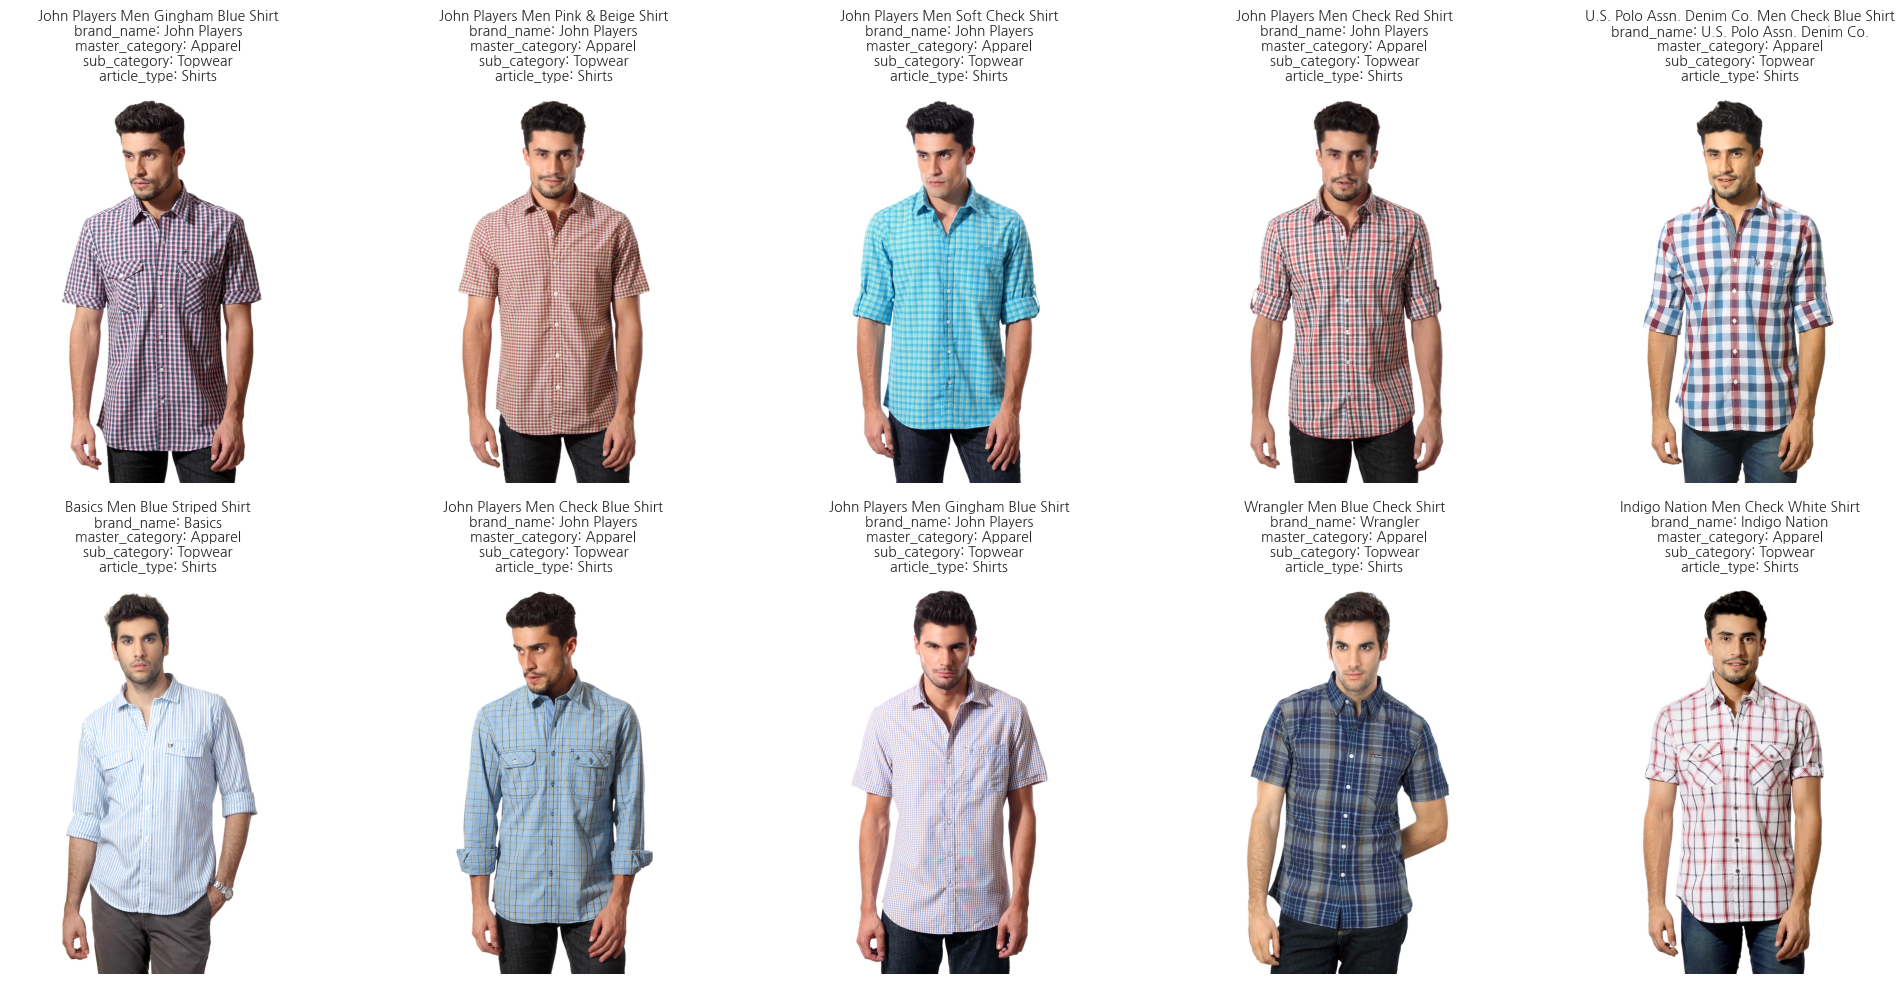

In [7]:
show_items(
    item_ids=list(candidates.keys()),
    df_item=df_item_metadata,
    image_dir=paths.base_path.joinpath("images"),
)